<a href="https://colab.research.google.com/github/Adhithyan6/Deep-Learning-Techniques/blob/master/BackPropogation/BackPropogation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [ ]:
class SimpleLinearModel(nn.Module):
    def __init__(self):
        super(SimpleLinearModel, self).__init__()
        self.fc = nn.Linear(1, 1)
    def forward(self, x):
        return self.fc(x)


In [ ]:
x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])


In [ ]:
model = SimpleLinearModel()

criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)


In [ ]:
gradients_w = []
gradients_b = []

In [ ]:
epochs = 1000
for epoch in range(epochs):
    y_pred = model(x)  # Forward pass
    loss = criterion(y_pred, y)  # Compute loss
    loss.backward()  # Backpropagation to compute gradients

    # Track gradients
    gradients_w.append(model.fc.weight.grad.item())  # Gradient of weight
    gradients_b.append(model.fc.bias.grad.item())    # Gradient of bias

    optimizer.step()  # Update weights
    optimizer.zero_grad()  # Zero the gradients after step

    # Print the loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [100/1000], Loss: 0.0101
Epoch [200/1000], Loss: 0.0055
Epoch [300/1000], Loss: 0.0030
Epoch [400/1000], Loss: 0.0017
Epoch [500/1000], Loss: 0.0009
Epoch [600/1000], Loss: 0.0005
Epoch [700/1000], Loss: 0.0003
Epoch [800/1000], Loss: 0.0002
Epoch [900/1000], Loss: 0.0001
Epoch [1000/1000], Loss: 0.0000


In [ ]:
print(f"Learned Weight: {model.fc.weight.item():.4f}")
print(f"Learned Bias: {model.fc.bias.item():.4f}")


Learned Weight: 1.9944
Learned Bias: 1.0165


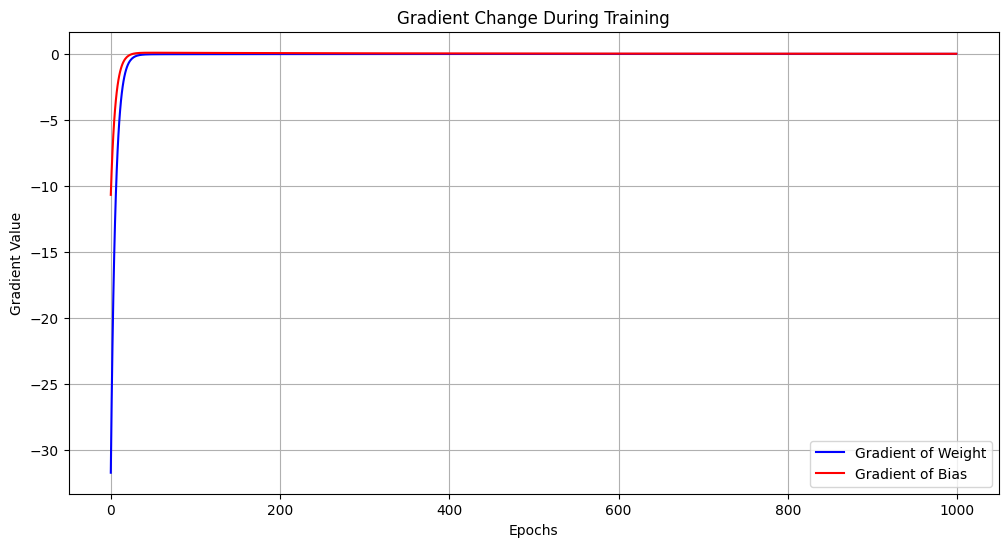

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(epochs), gradients_w, label='Gradient of Weight', color='blue')
plt.plot(range(epochs), gradients_b, label='Gradient of Bias', color='red')
plt.xlabel('Epochs')
plt.ylabel('Gradient Value')
plt.title('Gradient Change During Training')
plt.legend()
plt.grid(True)
plt.show()